In [1]:
import os, sys, torch
import numpy as np
import pandas as pd
import scanpy as sc

from scipy.stats import pearsonr, entropy
from torch.utils.data import DataLoader, TensorDataset


In [2]:
from src import _learner, _configure, PATH, _epsilon_module
from src import _linear, _helper_net
from src import _diffplot as dfp
from importlib import reload
pj = os.path.join

/home/wergillius/Project/diffuse_differentiate/script/path_n_util.py
/home/wergillius/Project/diffuse_differentiate/machine_config.json


In [3]:
adata_diff = sc.read_h5ad(
    f"{PATH.main_dir}/data/TFAtlas/GSE217460_210322_TFAtlas_differentiated.h5ad"
)

# to tensor

In [6]:
TF_onehot = pd.get_dummies(adata_diff.obs.TF).values
gene_X = adata_diff.X
X =  np.concatenate([gene_X, TF_onehot], axis=1)

Y = adata_diff.layers['a3_PathSampled_X'].copy()

train_idx = adata_diff.obs.split != 'test'
test_idx = adata_diff.obs.split == 'test'

x_train = torch.from_numpy(X[train_idx]).float()
x_test = torch.from_numpy(X[test_idx]).float()

Y_train = torch.from_numpy(Y[train_idx]).float()
Y_test = torch.from_numpy(Y[test_idx]).float()

In [7]:
train_ds = TensorDataset(x_train, Y_train)
train_dl = DataLoader(train_ds, batch_size=32, num_workers=8, shuffle=True)

test_ds = TensorDataset(x_test, Y_test)
test_dl = DataLoader(test_ds, batch_size=32,  num_workers=8, shuffle=False)

# model config and checkpoint

linear


In [14]:
L_M = _linear.Linear_model.load_from_checkpoint(f'{PATH.pth_dir}/lightning_logs/version_2/checkpoints/epoch=14-step=12165.ckpt',
                                        output_dim=4806, lr=3e-4, weight_decay=1e-3, input_dim=7341)

CAE

In [18]:
CAE = _linear.CAE_model.load_from_checkpoint(
    f"{PATH.pth_dir}/quick_CVAE/lightning_logs/version_12/checkpoints/epoch=370-step=300881.ckpt"
    )

# load GenDiff

In [33]:
# ridge params
prior_params = np.load("ridgemodel_params.npy")
prior_coef = prior_params[:,:-1]
prior_intercept = prior_params[:,-1]

In [17]:
# Embedding AE reconX
Embedding_AE = _linear.Embedding_model.load_from_checkpoint(
    "/home/wergillius/data/diffuse_differentiate/TF_atlas_quick/Embedding_CAE_deep_model_reconX/lightning_logs/version_0/checkpoints/epoch=172-step=140303.ckpt"
    )

In [34]:
# define GenDiff
GenDiff = _linear.Pretrained_GenDiff(
    gene_dim=4806, condition_dim=2535,
    pretrain_model=Embedding_AE,
    prior_coef=prior_coef, prior_intercept=prior_intercept,
    lr = 1e-5, weight_decay=1e-9)

In [174]:
GenDiff

Pretrained_GenDiff(
  (loss_fn): MSELoss()
  (train_r2_score): R2Score()
  (val_r2_score): R2Score()
  (pretrain_model): Embedding_model(
    (loss_fn): MSELoss()
    (train_r2_score): R2Score()
    (val_r2_score): R2Score()
    (embedder): Embedding(2535, 32)
    (encoder): MLP(
      (model): ModuleList(
        (0): Sequential(
          (0): Linear(in_features=4806, out_features=512, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ReLU()
        )
      )
    )
    (decoder): MLP(
      (model): ModuleList(
        (0): Sequential(
          (0): Linear(in_features=544, out_features=544, bias=True)
          (1): ReLU()
          (2): BatchNorm1d(544, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): Sequential(
          (0): Linear(in_features=544, out_features=4806, bias=True)
        )
      )
    )
  )
  (fc_output): Linear(in_features=734

In [173]:
next(GenDiff.parameters()).size()

torch.Size([2535, 32])

# Predict Y 

In [37]:
with torch.no_grad():
    Ypred_GD = GenDiff(x_test)
    Ypred_CAE = CAE(x_test)
    Ypred_LM = L_M(x_test)

# dict of tensors
Ypred_dict = {
    "CAE" : Ypred_CAE,
    "Ridge" : Ypred_LM,
    "GenDiff" : Ypred_GD,
}

In [40]:
# save the test set prediction

save_dir = f"{PATH.main_dir}/result/TFAtlas/testset_pred"

np.save(f"{save_dir}/GenDiff_TestSet_pred.npy", Ypred_GD.numpy())
np.save(f"{save_dir}/LinearModel_TestSet_pred.npy", Ypred_LM.numpy())
np.save(f"{save_dir}/CAE_TestSet_pred.npy", Ypred_CAE.numpy())

# compute r2

### all genes

In [61]:
dfs = []

for method, Ypred in Ypred_dict.items():
    r_df = evaluate_r(Y_test, Ypred)
    r_df['method'] = method

    dfs.append(r_df)

performance_df = pd.concat(dfs, axis=0)


In [66]:
# save
performance_df.to_csv(f"{save_dir}/LM_CAE_GD_pred_r2.csv", index=False)

# resume

In [10]:
save_dir = f"{PATH.main_dir}/result/TFAtlas/testset_pred"

Ypred_GD = np.load(f"{save_dir}/GenDiff_TestSet_pred.npy")
Ypred_LM = np.load(f"{save_dir}/LinearModel_TestSet_pred.npy")
Ypred_CAE = np.load(f"{save_dir}/CAE_TestSet_pred.npy")

# dict of tensors
Ypred_dict = {
    "CAE" : torch.from_numpy(Ypred_CAE),
    "Ridge" : torch.from_numpy(Ypred_LM),
    "GenDiff" : torch.from_numpy(Ypred_GD),
}

# save
performance_df = pd.read_csv(f"{save_dir}/LM_CAE_GD_pred_r2.csv")

# visualize r2

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='ticks', font_scale=1.3)

In [19]:
def rgb_to_hex(rgb_ls): 
    return '#{:02x}{:02x}{:02x}'.format(*rgb_ls)

palette = {"Ridge": rgb_to_hex([246,218,214]),
            "CAE": rgb_to_hex([246,217,177]),
            "GenDiff": rgb_to_hex([185,220,239])
            }

### hvg genes

In [11]:
hvgs = adata_diff.var['dispersions_norm'].nlargest(200).index

hvg_df = performance_df.query("`gene` in @hvgs")

### marker genes

In [12]:
# make a summary of cell type 
celltype, counts = np.unique(adata_diff.obs.cell_type.values, return_counts=True)
celltype_sum_df =pd.DataFrame({'cell_type':celltype, 'counts':counts})

# remove most-dominant cell types and minor cell types
select_celltypes = celltype_sum_df.query("100 <= `counts` <10000" ).set_index('cell_type')

# select those with positive in names
select_celltypes = select_celltypes.filter(axis=0,
                        regex=r"^((?!positive).)*$")

In [13]:
train_ad = adata_diff[adata_diff.obs.split != 'test']
ad_select_cells = train_ad[train_ad.obs.cell_type.isin(select_celltypes.index)]

In [41]:
# condition exposure in train set
TF, counts = np.unique(train_ad.obs.TF.values, return_counts=True)
proportion = counts/train_ad.shape[0]

TF_exposure_lookup = dict(zip(TF,counts))
TF_exposure_df =pd.DataFrame({'TF':TF, 'proportion':proportion})

#### compute entropy

In [4]:
# load the cell type mapping result
celltype_mapping = pd.read_csv("../Figure3B_celltype_mapping.csv")
P_c = celltype_mapping.filter(like='prediction.score', axis=1).values

# compute entropy and save to adata
celltype_mapping['Celltype_Entropy'] = entropy(P_c, axis=1)
celltype_mapping = celltype_mapping.loc[adata_diff.obs_names]
adata_diff.obs['Celltype_Entropy'] = celltype_mapping['Celltype_Entropy']

In [10]:
X_pos = adata_diff.X - adata_diff.X.min(axis=0, keepdims=True) + 1e-5
adata_diff.obs['Expresion_entropy'] = entropy(X_pos,axis=1)

In [11]:
adata_diff.write_h5ad(
     f"{PATH.main_dir}/data/TFAtlas/GSE217460_210322_TFAtlas_differentiated.h5ad"
)

backgound = adata_diff.obs.sample(100).index

<Axes: title={'center': 'Celltype_Entropy'}, xlabel='UMAP1', ylabel='UMAP2'>

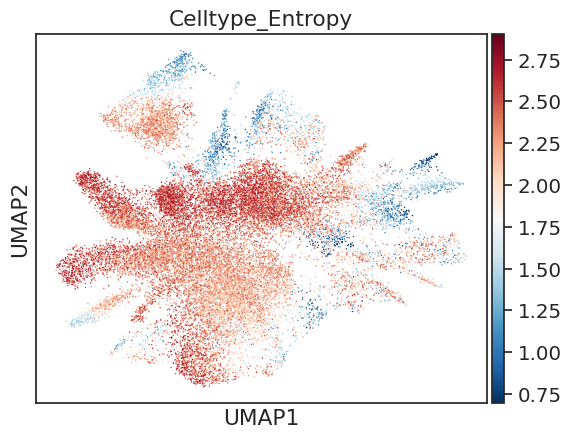

In [20]:
ax = plt.subplot()
sc.pl.umap(adata_diff, color='Celltype_Entropy', ax=ax, show=False,cmap='RdBu_r')

<Axes: title={'center': 'cell_type'}, xlabel='UMAP1', ylabel='UMAP2'>

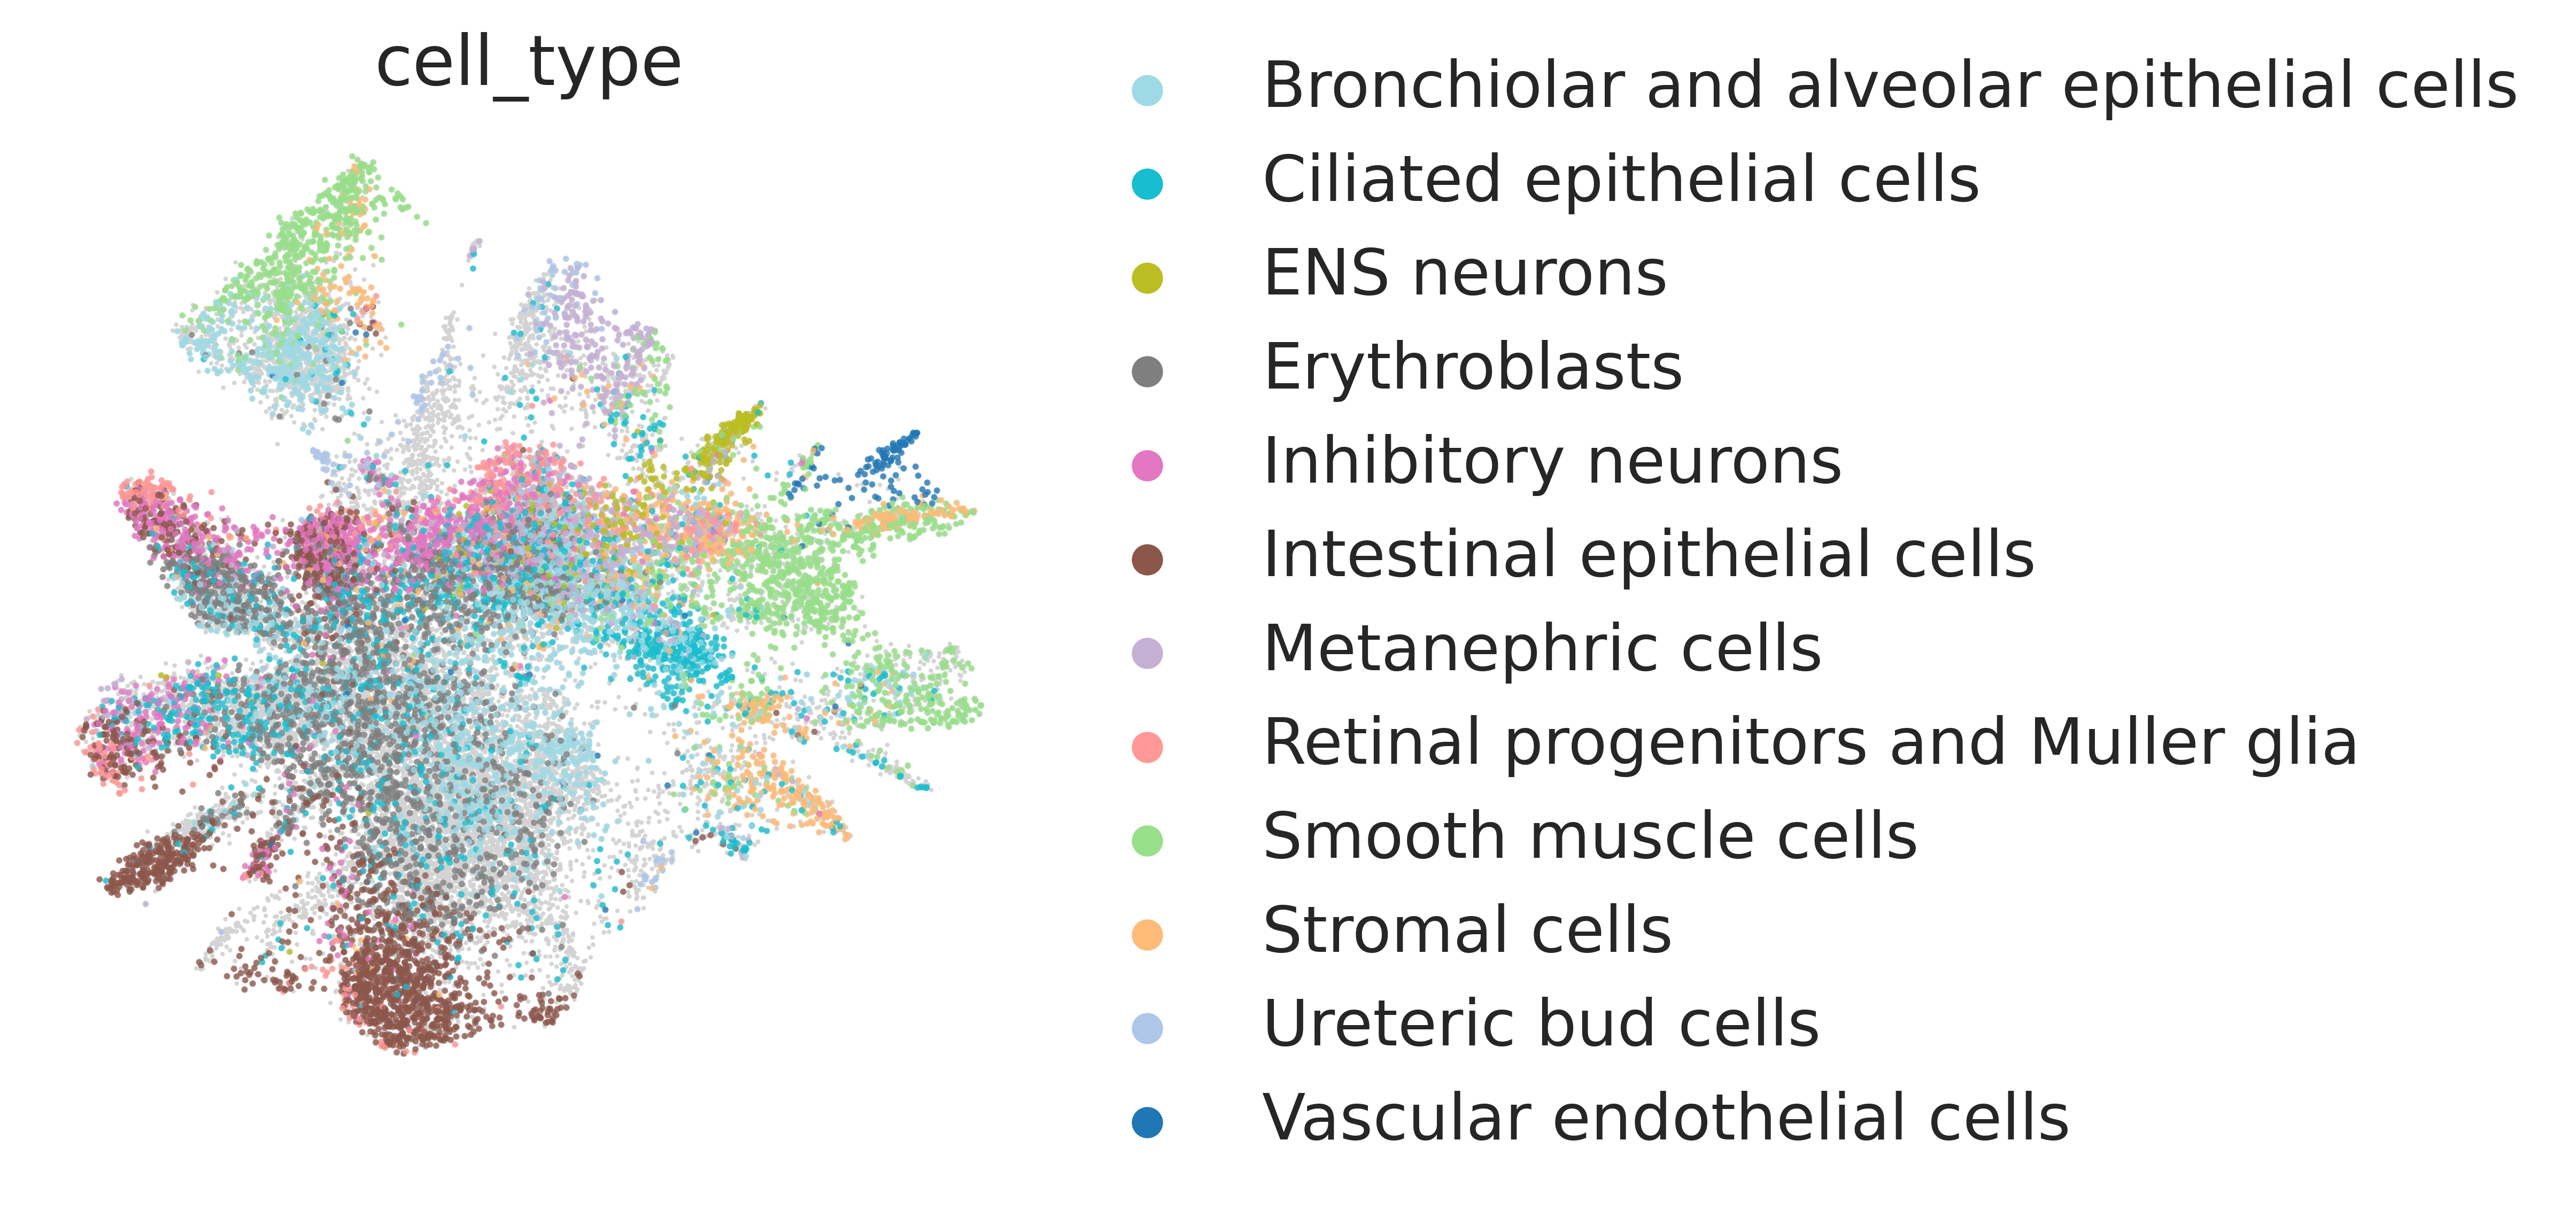

In [21]:
fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=600)

sc.pl.umap(adata_diff, alpha=0.95, ax=ax, show=False)
sc.pl.umap(ad_select_cells, color='cell_type', alpha=0.75,
           palette = 'tab20_r', frameon=False,
           ax=ax, show=False)

In [22]:
sc.tl.rank_genes_groups(adata=ad_select_cells, 
        groupby='cell_type', method='wilcoxon')

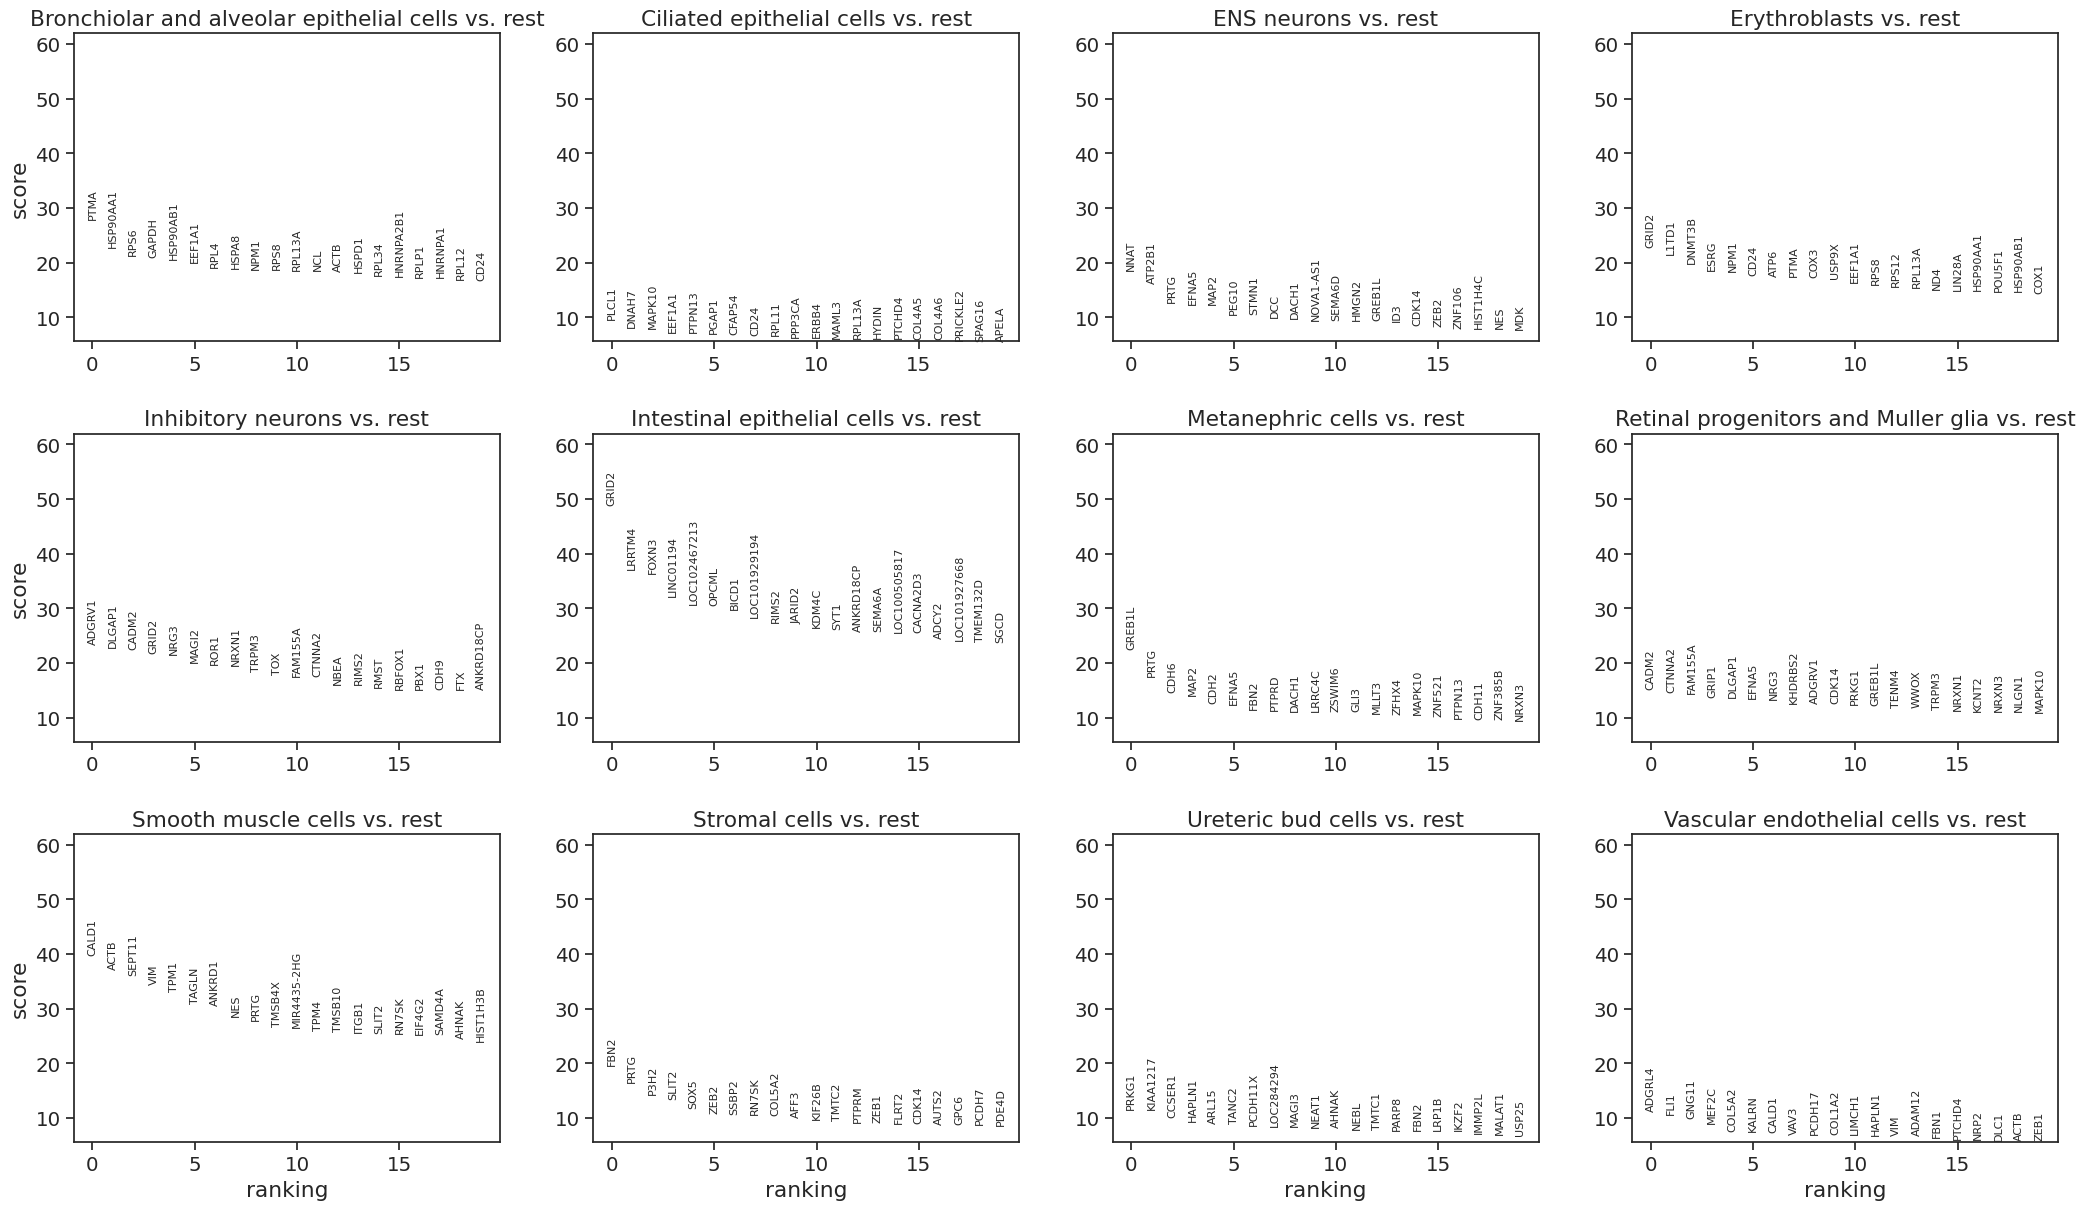

In [23]:
sc.pl.rank_genes_groups(ad_select_cells)

In [24]:
deg_df = sc.get.rank_genes_groups_df(ad_select_cells, group=select_celltypes.index,
                                     pval_cutoff=1e-90)
deg_df.names.nunique()

128

In [25]:
degs = deg_df.names.unique()
deg_df = performance_df.query("`gene` in @degs")

merge three box

In [196]:
sns.set_theme(style='ticks', font_scale=1.5)

Text(0.5, 1.0, '128 Marker genes \n of 12 celltypes')

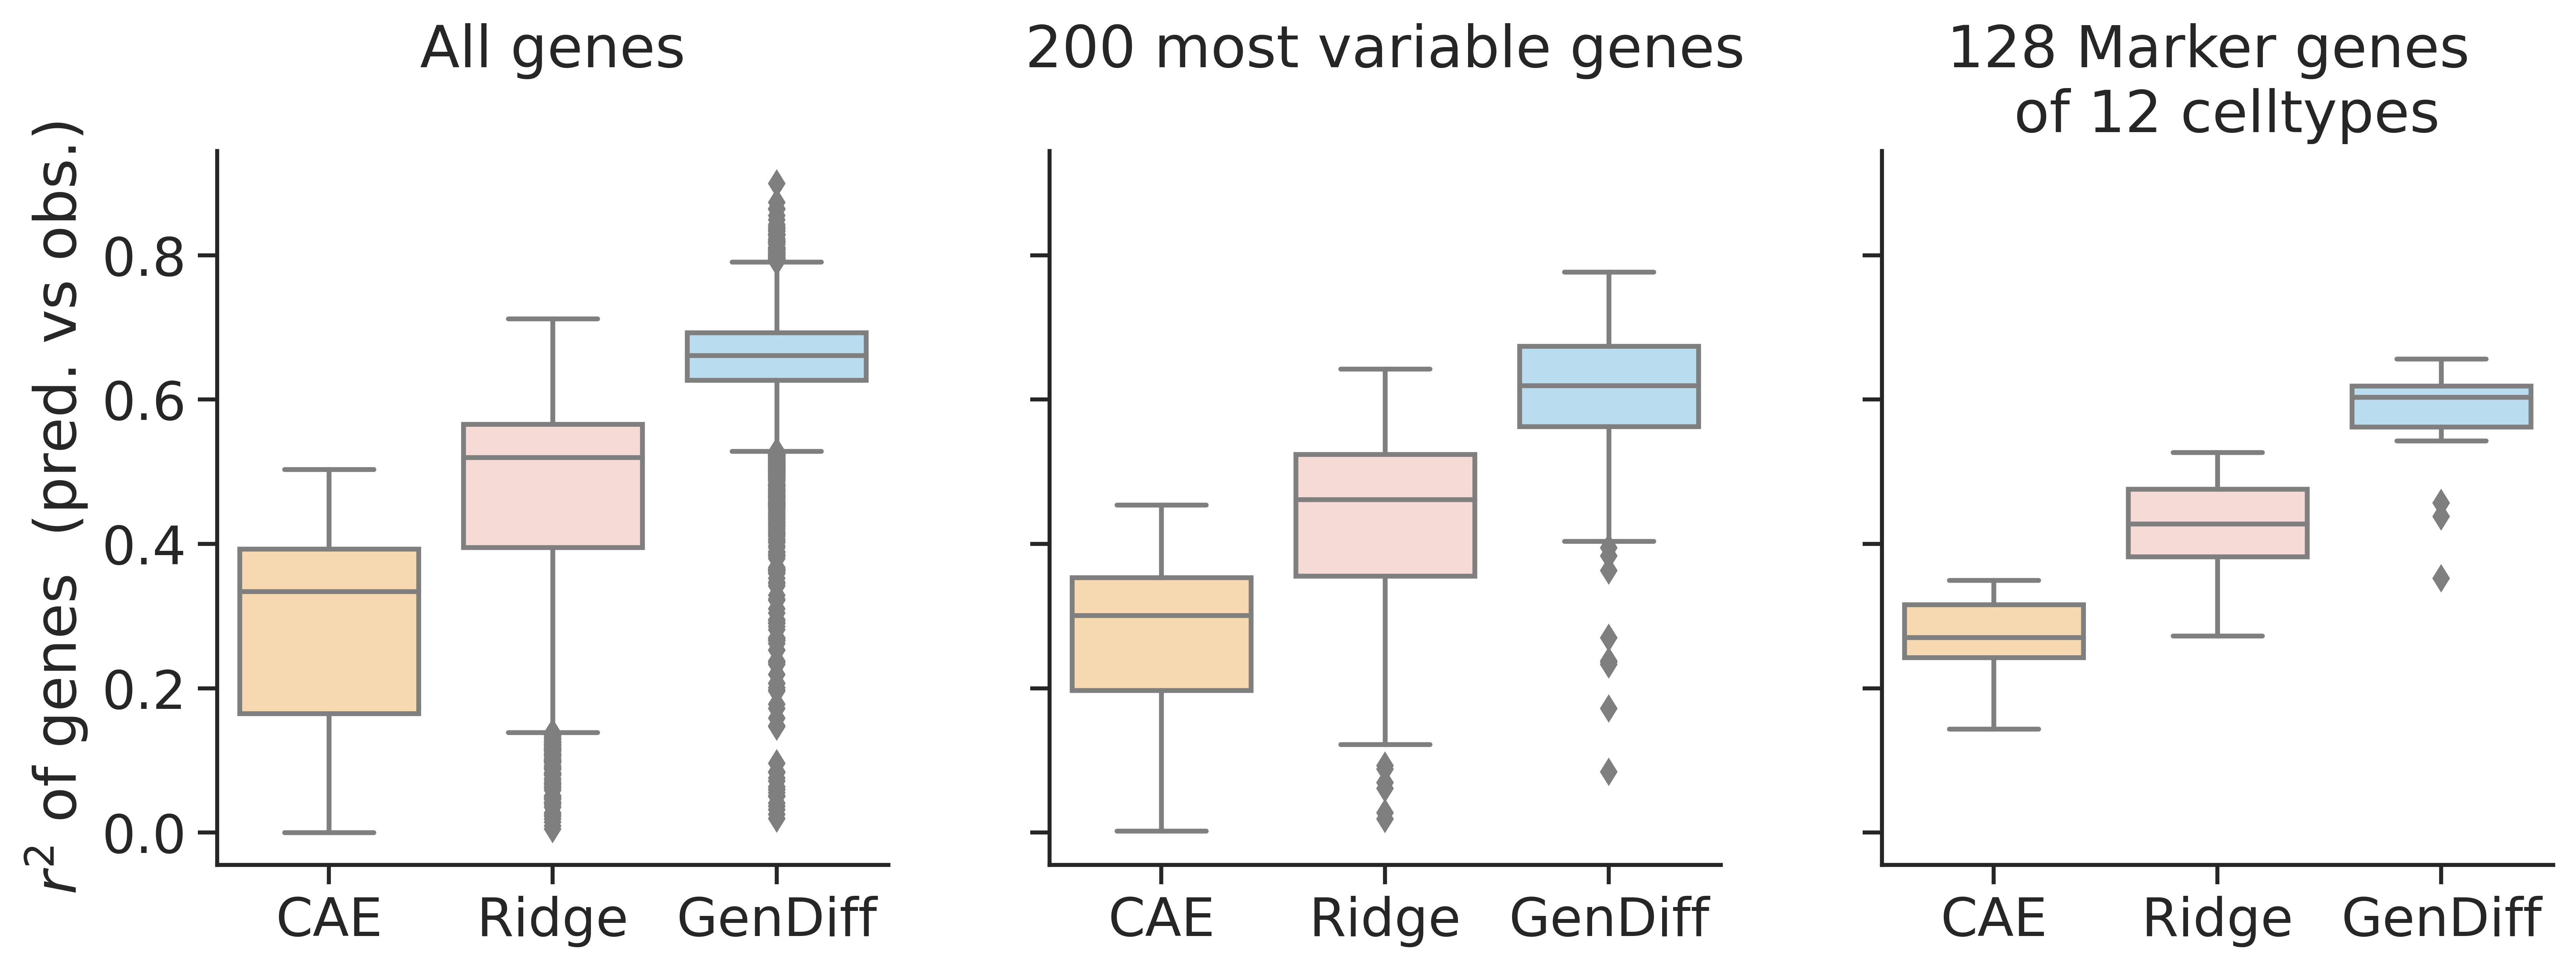

In [93]:
fig, axs = plt.subplots(1,3, figsize=(13,4), dpi=600, gridspec_kw= {'wspace':0.24}, sharey=True)

ax = axs[0]
sns.boxplot(data=performance_df, x='method', y='r2',  
        palette=palette, saturation=1, ax=ax)
sns.despine(ax=ax)

ax.set_ylabel(r"$r^2$ of genes"+ "  (pred. vs obs.)")
ax.set_xlabel("")
ax.set_title('All genes\n')

ax = axs[1]
sns.boxplot(data=hvg_df, x='method', y='r2',  
        palette=palette, saturation=1, ax=ax)
sns.despine(ax=ax)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title('200 most variable genes\n')

ax = axs[2]
sns.boxplot(data=deg_df, x='method', y='r2',  
        palette=palette, saturation=1, ax=ax)
sns.despine(ax=ax)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title('128 Marker genes \n of 12 celltypes')

#

# Compute Cosine similarity

In [26]:
test_ad = adata_diff[adata_diff.obs.split == 'test']

In [27]:
celltype_mapping = pd.read_csv("../Figure3B_celltype_mapping.csv")
P_c = celltype_mapping.filter(like='prediction.score', axis=1).values

celltype_mapping['Celltype_Entropy'] = entropy(P_c, axis=1)
celltype_mapping = celltype_mapping.loc[adata_diff.obs_names]

adata_diff.obs['Celltype_Entropy'] = celltype_mapping['Celltype_Entropy']

In [28]:
from torch.nn.functional import cosine_similarity

In [29]:
cosine_dict = {}
with torch.no_grad():
    for method, ypred in Ypred_dict.items():
        cosine_dict[method] = cosine_similarity(ypred, Y_test, dim=1).numpy()

In [30]:
# 
cosine_df = pd.DataFrame(cosine_dict)
cosine_df['cell_barcode'] = test_ad.obs_names
cosine_df.index = test_ad.obs_names

In [31]:
# merge
cosine_df = cosine_df.merge(
    test_ad.obs[['TF','Celltype_Entropy']],
    left_index=True, right_index=True
    )

In [32]:
cosine_melt = cosine_df.melt(
    id_vars=['cell_barcode','TF','Celltype_Entropy'],
    value_name='cosine similarity', 
    var_name='method'
)

In [51]:
cosine_melt['TF_exposure'] = cosine_melt['TF'].map(TF_exposure_lookup).apply(lambda x: np.log10(x+1))

In [139]:
cosine_melt['Entropy_bin'] = pd.cut(cosine_melt['Celltype_Entropy'].values,
                                     bins=10, labels=range(1,11))

### cos of all cells

Text(0.5, 1.0, ' \n')

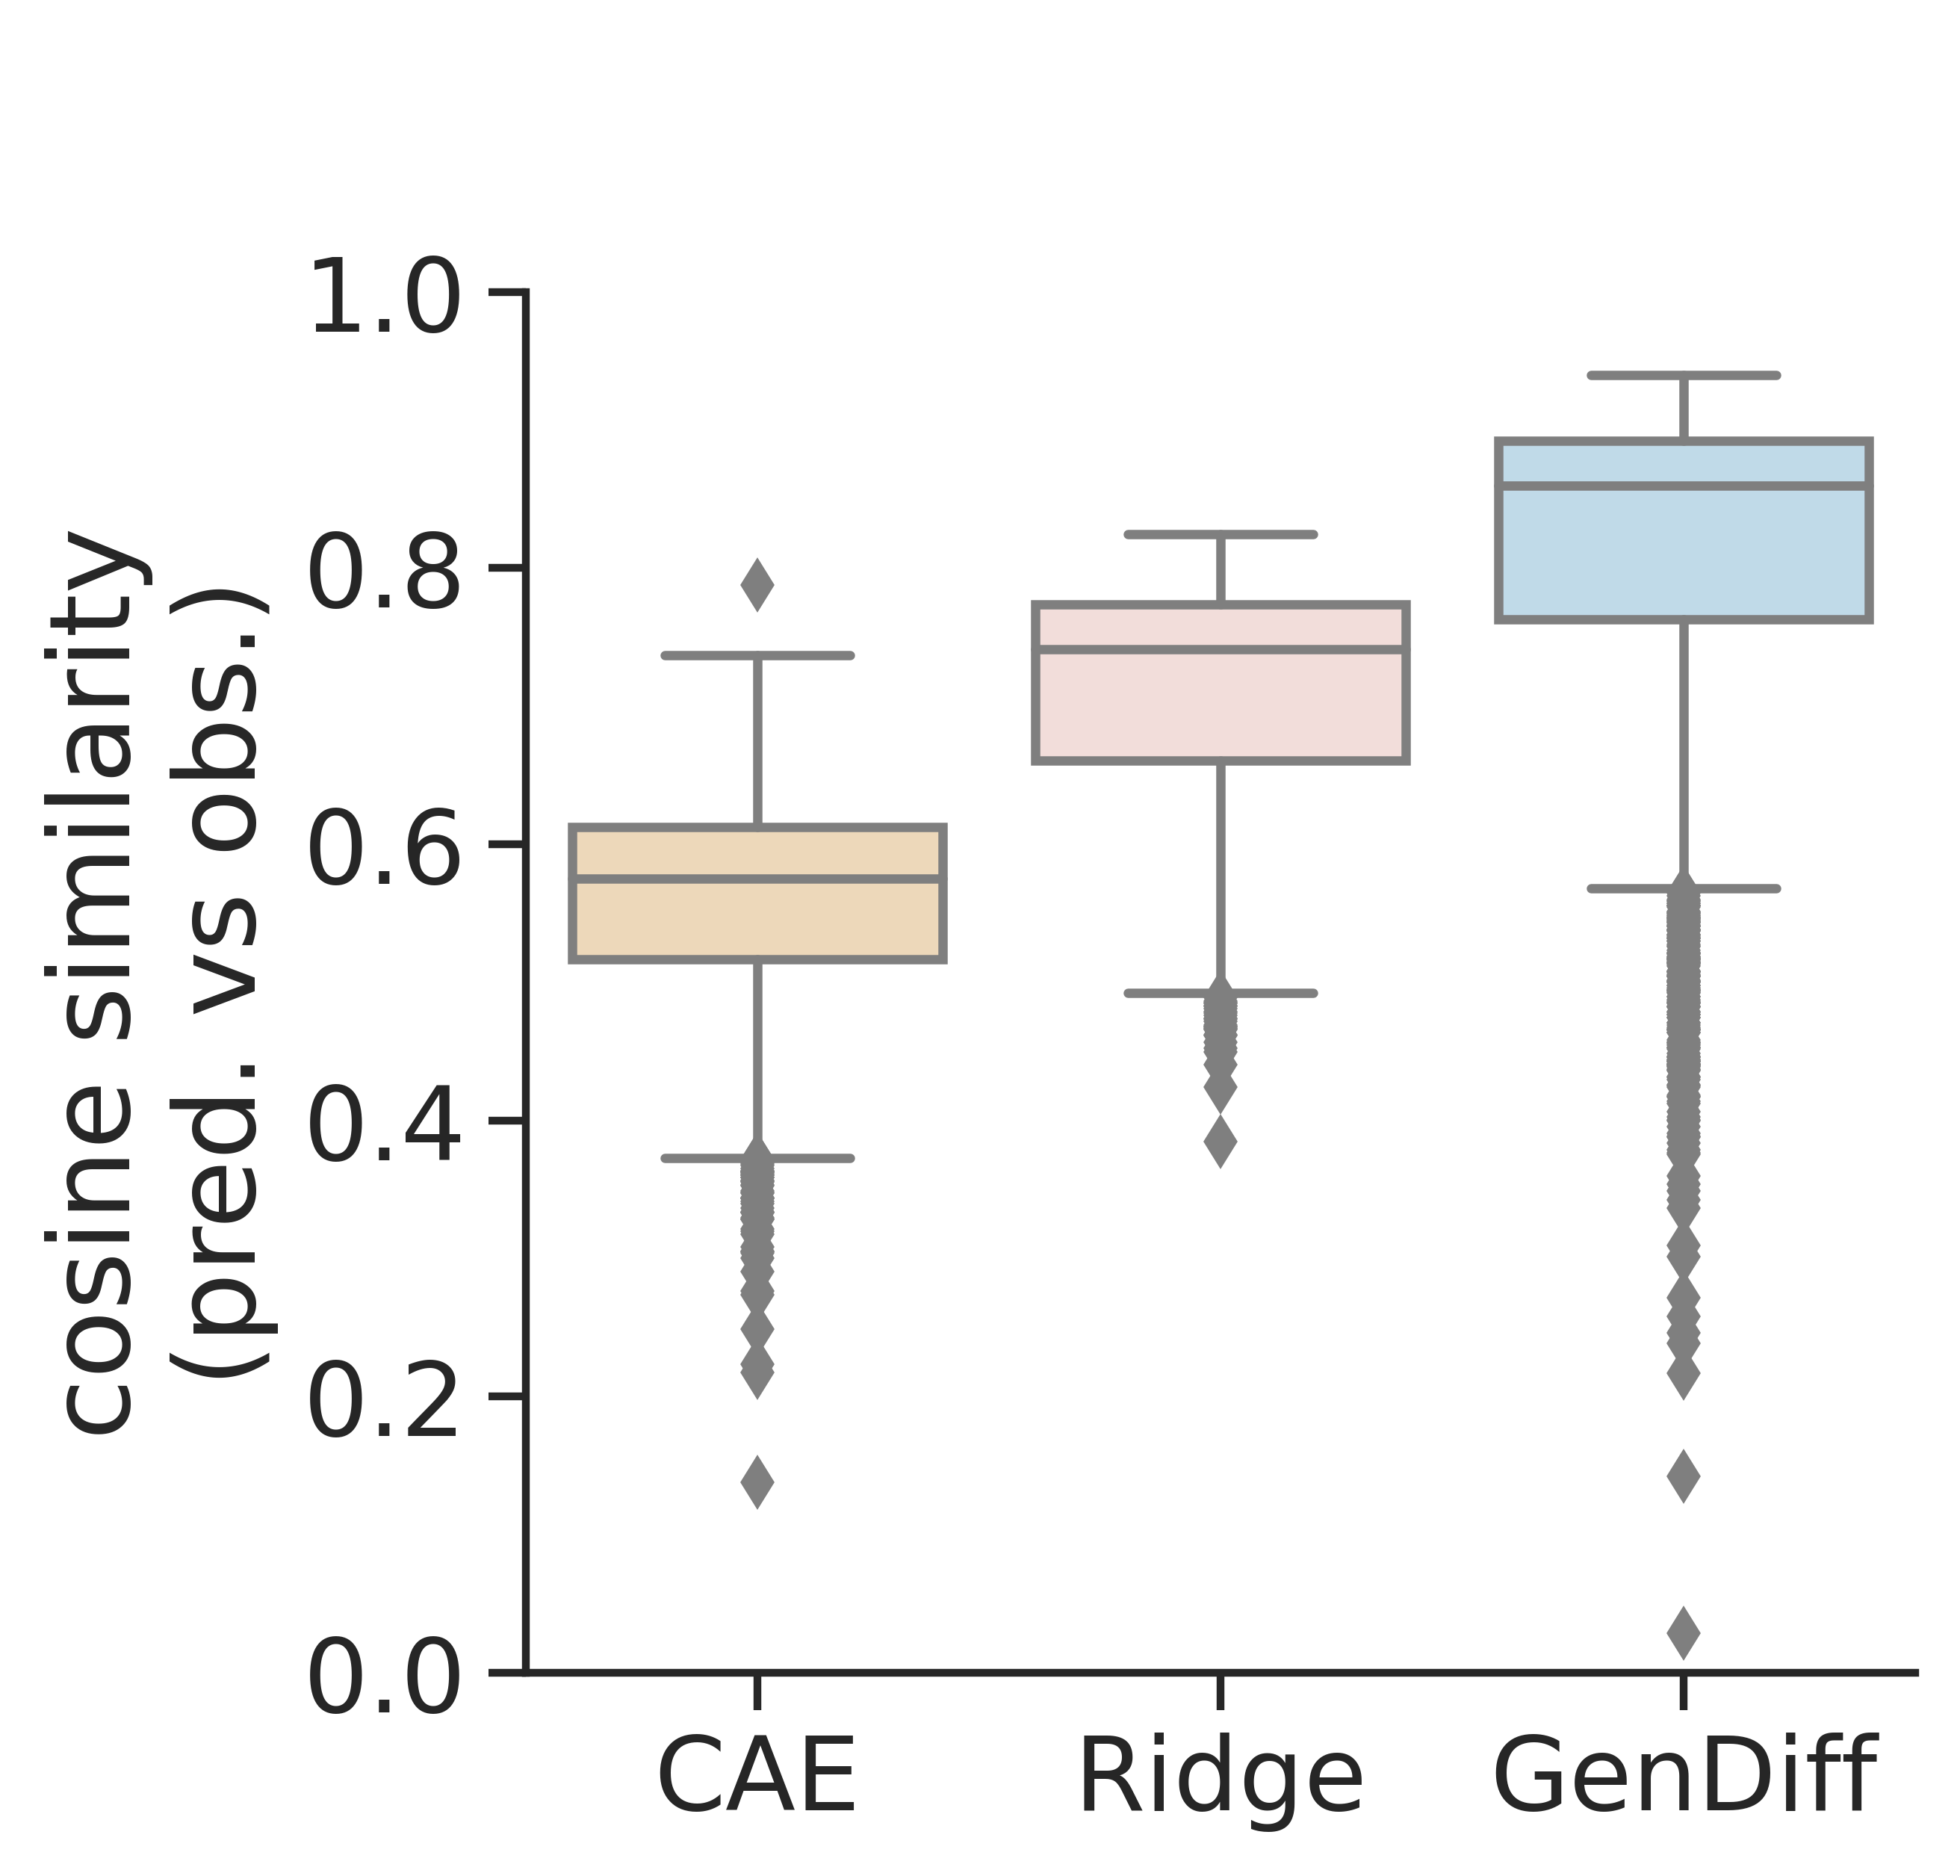

In [89]:
fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=600)

sns.boxplot(data=cosine_melt, x='method',
            y='cosine similarity', 
            palette=palette
            )
sns.despine(ax=ax)
ax.set_ylim(0,1)
ax.set_xlabel("")
ax.set_ylabel("cosine similarity\n(pred. vs obs.)")
ax.set_title(" \n")

In [142]:
cosine_melt['confident transition'] = cosine_melt['cosine similarity'].gt(0.7)
confident_sum = cosine_melt.groupby(['Entropy_bin','method']).agg({"confident transition":'mean'})

confident_sum = confident_sum.reset_index()

Text(0, 0.5, 'cosine similarity')

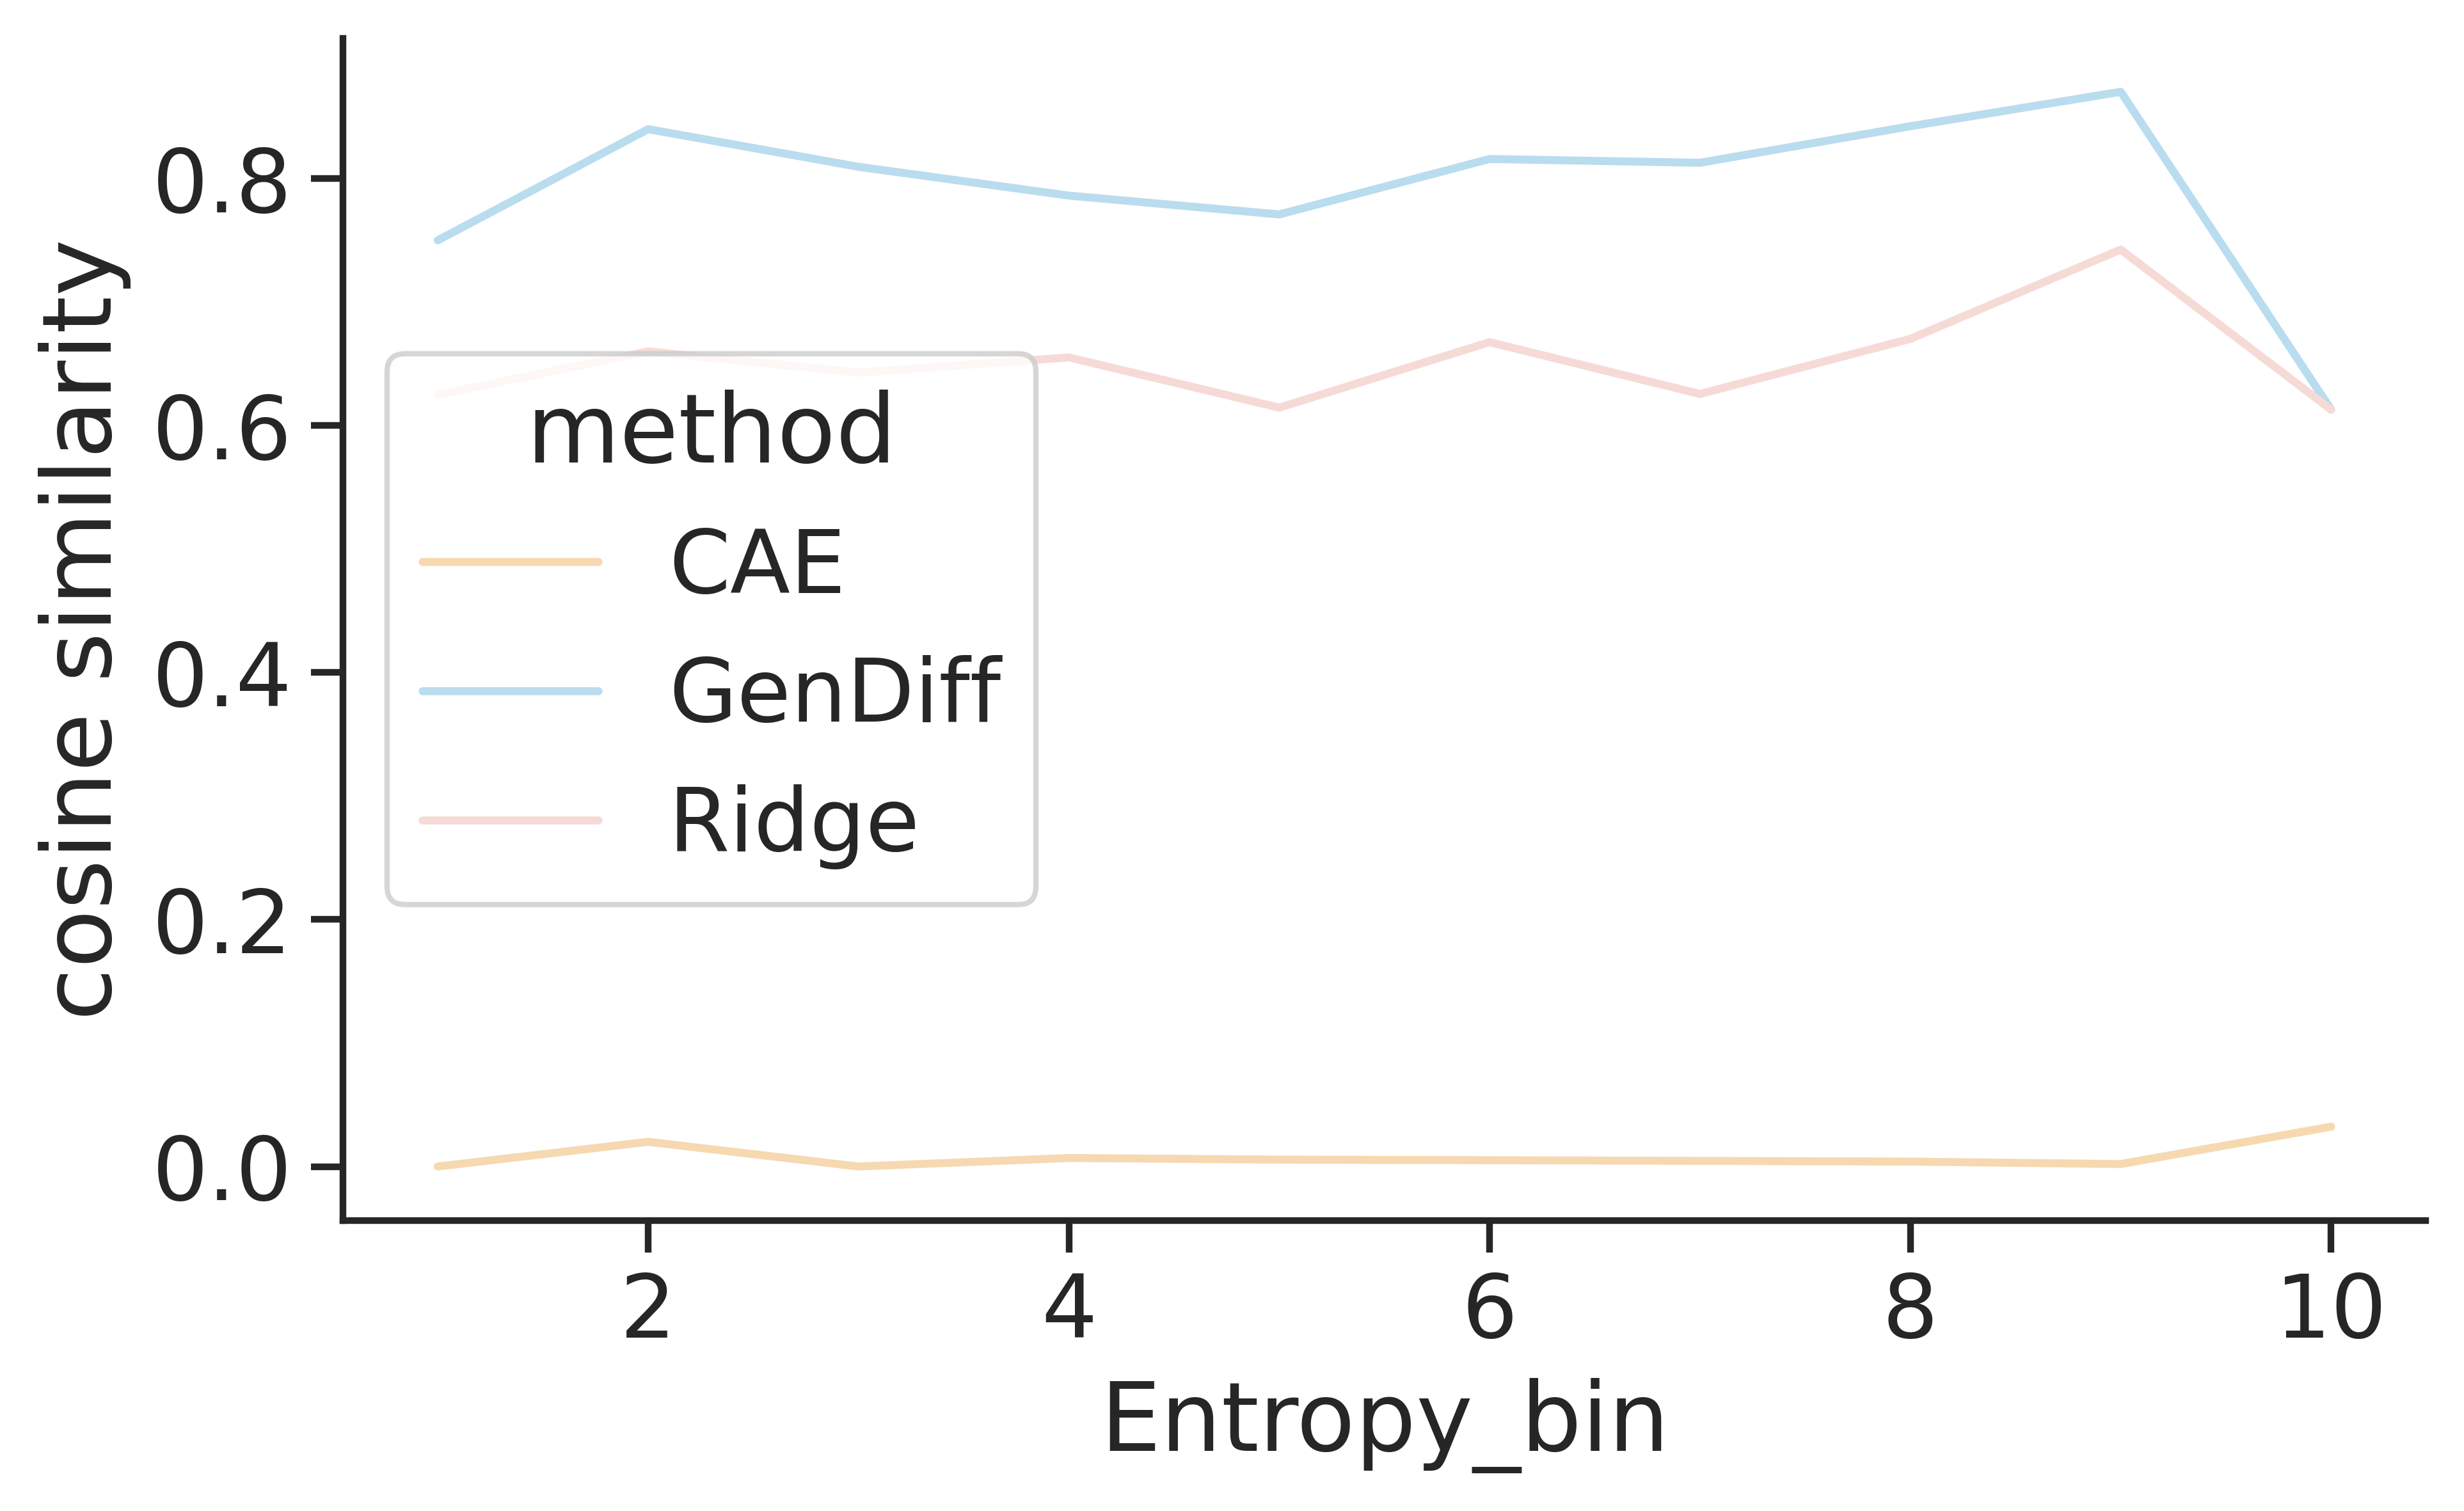

In [143]:
fig, ax = plt.subplots(1,1, figsize=(7,4), dpi=600)
sns.set_theme(style='ticks',
              font_scale=1.5)

sns.lineplot(data=confident_sum, hue='method',
            y='confident transition', x='Entropy_bin',
            palette=palette, ax=ax)

sns.despine(ax=ax)

# ax.legend(ncol=3, title='', 
#           bbox_to_anchor=(0.05,0.95,0.8,0.05), 
#           )

ax.set_ylabel('cosine similarity')
# ax.set_xlabel("TF exposure in train set \n(number of cells)");
# ax.set_xticklabels(np.floor(np.power(10, np.arange(0,3,0.5))).astype(int));

### cos by condition exposure

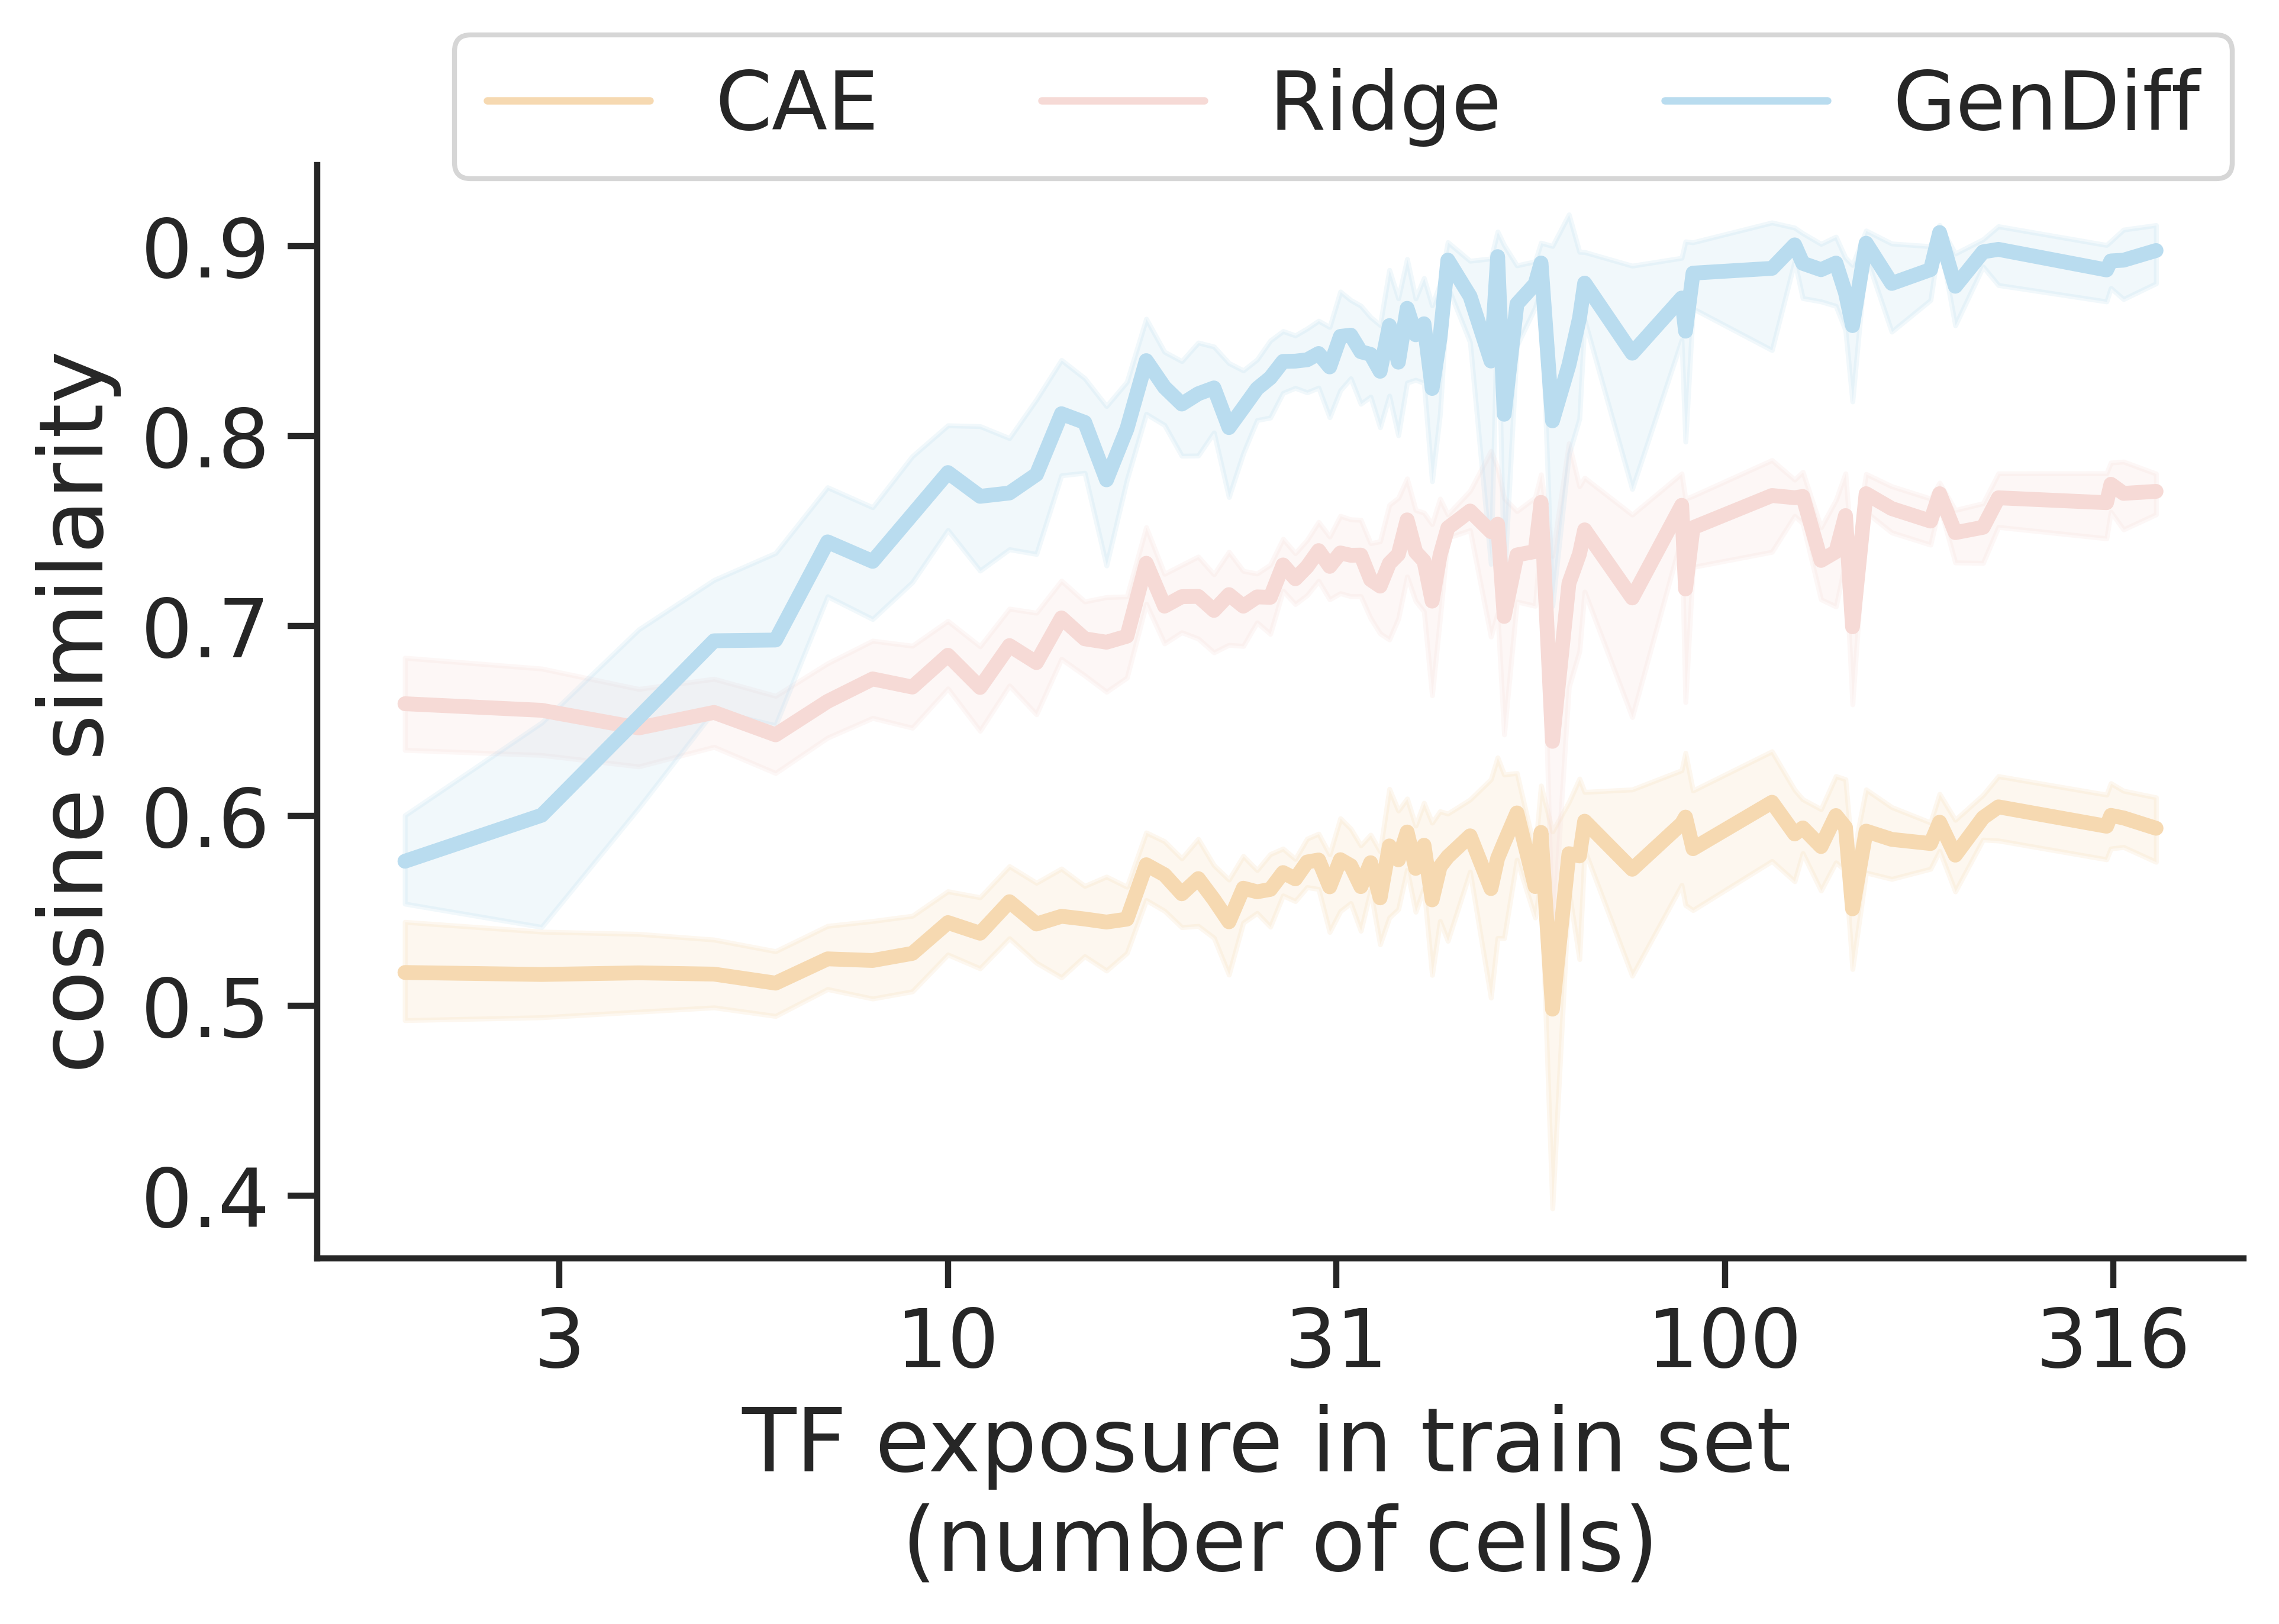

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(7,4), dpi=600)
sns.set_theme(style='ticks',
              font_scale=1.5)

sns.lineplot(data=cosine_melt, hue='method', x='TF_exposure',
            y='cosine similarity', alpha=1, linewidth=3,
            palette=palette,ax=ax)

sns.despine(ax=ax)

ax.legend(ncol=3, title='', 
          bbox_to_anchor=(0.05,0.95,0.8,0.05), 
          )

ax.set_ylabel('cosine similarity')
ax.set_xlabel("TF exposure in train set \n(number of cells)");
ax.set_xticklabels(np.floor(np.power(10, np.arange(0,3,0.5))).astype(int));